<img src="imgs\banner_fcd.jpg" alt="bannersp" width="1100"  height="150">

## <span style="color:#2F749F;"><strong>📦 Sesión práctica 4: Detección de datos atípicos</strong></span>
---
<p align="right">
  <a href="https://github.com/mariabda2/intro_data_2026/blob/main/sesiones_practicas/sp_4_maria_bernarda_salazar.ipynb?clone=true" target="_blank">
    <img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Abrir en Colab"/>
  </a>
</p>


## <span style="color:black;"><strong>Datos del estudiante</strong></span>

Relacione sus datos y los del compañero de trabajo

# <span style="color:#2F749F;"><strong>Ejercicio 1: Intervalo IQR</strong></span>

A partir de siguiente código:

1. Ajusta el código para mejorar la interpretación de la gráfica. Mínimo debes:
   - Indicar los nombres de los ejes
   - Incluir legenda para comprender lo que esté incluído en la gráfica
2. Generar máximo 5 líneas de análisis sobre lo que observas en términos de defición de atípicos sobre tú gráfica final

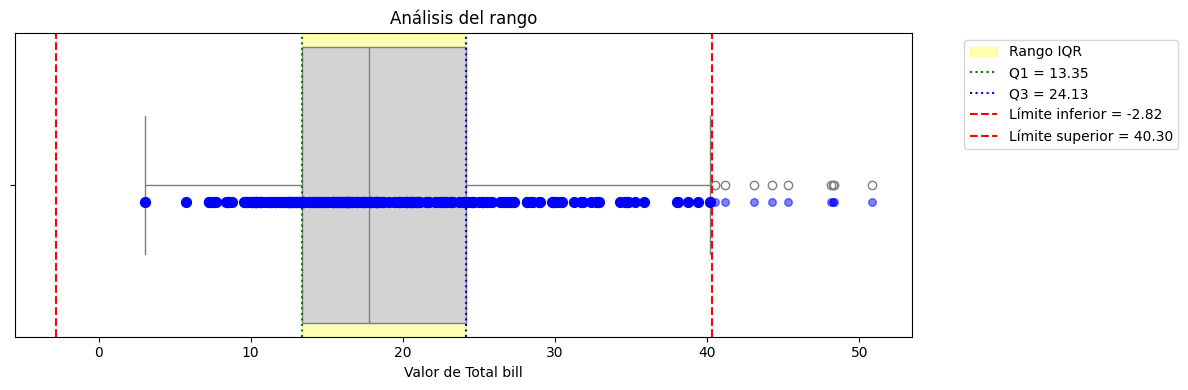

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

tips = sns.load_dataset("tips")
total_bill = tips["total_bill"].values
Q1, Q3 = np.percentile(total_bill, [25, 75])
IQR = Q3 - Q1
lim_inf = Q1 - 1.5 * IQR
lim_sup = Q3 + 1.5 * IQR
data_a = total_bill[(total_bill < lim_inf) | (total_bill > lim_sup)]
data_b = total_bill[(total_bill >= lim_inf) & (total_bill <= lim_sup)]

plt.figure(figsize=(12,4))
sns.boxplot(x=total_bill, color="lightgray")
plt.title("total_bill")
plt.axvspan(Q1, Q3, color='yellow', alpha=0.3, label='Rango IQR')
plt.axvline(Q1, color='green', linestyle=':', label=f'Q1 = {Q1:.2f}')
plt.axvline(Q3, color='blue', linestyle=':', label=f'Q3 = {Q3:.2f}')
plt.axvline(lim_inf, color='red', linestyle='--', label=f'Límite inferior = {lim_inf:.2f}')
plt.axvline(lim_sup, color='red', linestyle='--', label=f'Límite superior = {lim_sup:.2f}')


plt.xlabel('Valor de Total bill')
plt.title('Análisis del rango')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.scatter(data_a, [0.05]*len(data_a), color="blue", s=30, alpha=0.5)
plt.scatter(data_b, [0.05]*len(data_b), color="blue", s=50, zorder=5)
plt.show()


**Análisis**:
*   Los datos atípicos ubicados a la derecha del boxplot coinciden con aquellos que superan el límite superior definido, lo cual indica la presencia de valores extremos altos. La cercanía entre el límite del boxplot y la línea roja sugiere que existen datos próximos a ese umbral que influyen en su posición. En el límite inferior no se identifican valores atípicos, ya que los datos se concentran dentro del rango esperado. La separación entre los límites inferiores se debe a la ausencia de valores extremos en esa zona. En general, la distribución muestra asimetría hacia la derecha con presencia de outliers superiores.


# <span style="color:#2F749F;"><strong>Ejercicio 2: Graficos de dispersión</strong></span>

A partir de siguiente código:

1. Ajusta el código para mejorar la interpretación de la gráfica. Mínimo debes:
   - Indicar los nombres de los ejes
   - Incluir legenda para comprender lo que esté incluído en la gráfica
2. Generar máximo 5 líneas de análisis sobre lo que observas en términos de defición de atípicos sobre tú gráfica final

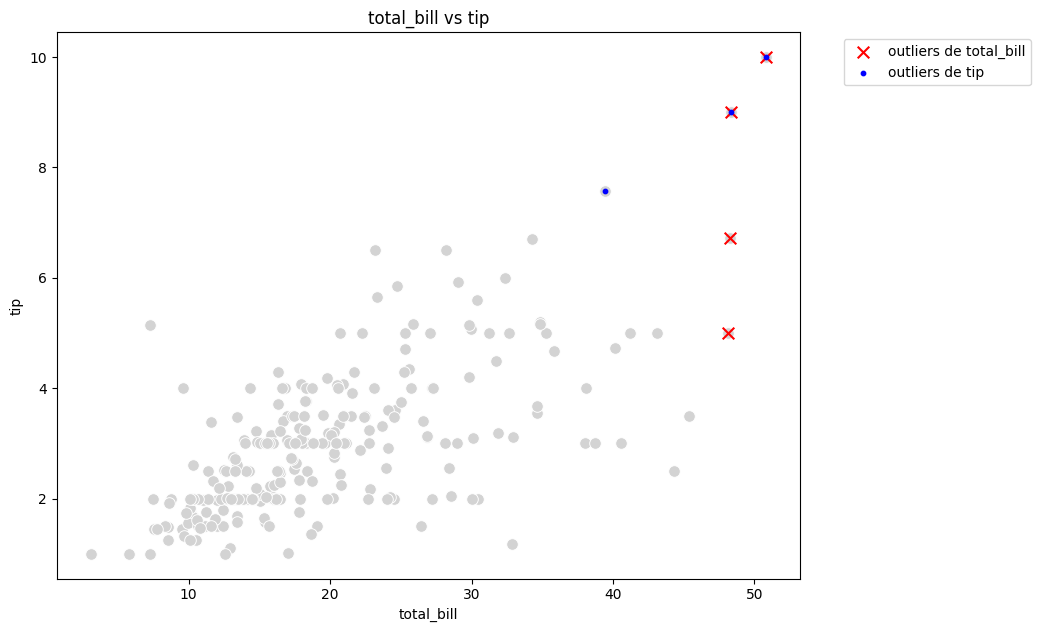

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.stats import zscore

tips = sns.load_dataset("tips")
df = pd.DataFrame({'valor_total_bill': tips["total_bill"], 'valor_tips' : tips["tip"]})


# TOTAL TIPS
# Calcular Z score
df['z_score1'] = zscore(df['valor_total_bill'])
df['outlier_z1'] = df['z_score1'].abs() > 3
# Media y desviación estándar global
mu = df['valor_total_bill'].mean()
sigma = df['valor_total_bill'].std(ddof=0)
# Calcular z-score
df['z_score1'] = (df['valor_total_bill'] - mu) / sigma

# TIPS
# Calcular Z score
df['z_score2'] = zscore(df['valor_tips'])
df['outlier_z2'] = df['z_score2'].abs() > 3
# Media y desviación estándar global
mu = df['valor_tips'].mean()
sigma = df['valor_tips'].std(ddof=0)
# Calcular z-score
df['z_score2'] = (df['valor_tips'] - mu) / sigma

x = tips["total_bill"].values
y = tips["tip"].values

plt.figure(figsize=(8,6))
sns.scatterplot(x=x, y=y, s=70, color="lightgray")
plt.scatter(x[df['outlier_z1']], y[df['outlier_z1']], color="red", s=70, marker="x", label="outliers de total_bill")
# otliers de tip
plt.scatter(x[df['outlier_z2']], y[df['outlier_z2']], color="blue", s=10, marker="o", label="outliers de tip")
plt.tight_layout()
plt.title("total_bill vs tip")
plt.xlabel("total_bill")
plt.ylabel("tip")

plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')

plt.show()

**Análisis**:
*  En la variable tip se identifican 3 valores atípicos, mientras que en total_bill se observan 4, representados como puntos alejados del patrón general del gráfico. Dos de estos valores coinciden en ambas variables, lo que sugiere casos donde cuentas altas están asociadas a propinas inusualmente elevadas.
Estos puntos se consideran atípicos porque se encuentran fuera del comportamiento esperado de la mayoría de los datos.La detección depende del umbral definido (por ejemplo, z-score > 3), por lo que el número de outliers puede variar si se ajusta este criterio.

---
En general, estos resultados podrían indicar clientes particularmente generosos o situaciones atípicas en el consumo.

# <span style="color:#2F749F;"><strong>Ejercicio 3: Histogramas y funciones de densidad</strong></span>

A partir de siguiente código:

1. Ajusta el código para mejorar la interpretación de la gráfica. Mínimo debes:
   - Indicar los nombres de los ejes
   - Incluir legenda para comprender lo que esté incluído en la gráfica
2. Generar máximo 5 líneas de análisis sobre lo que observas en términos de defición de atípicos sobre tú gráfica final

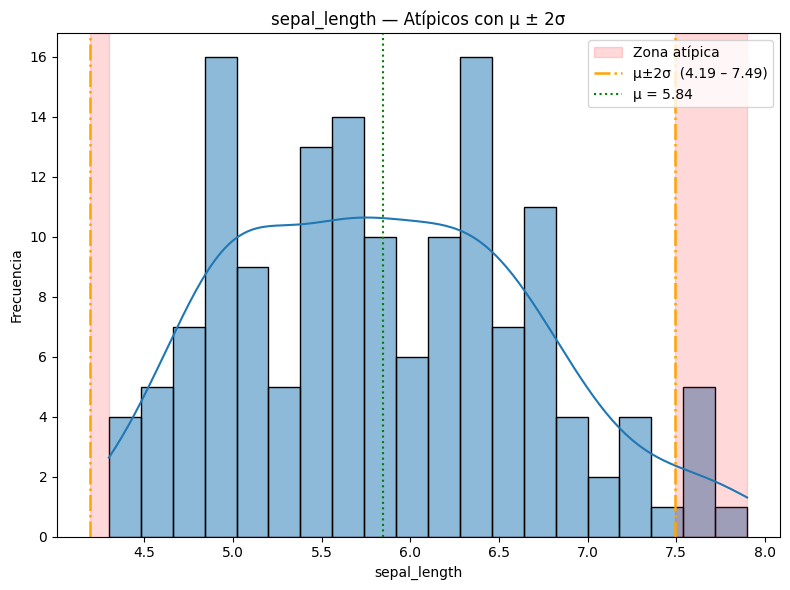

μ = 5.84,  σ = 0.83
Límites: [4.19, 7.49]
Atípicos (6): [np.float64(7.6), np.float64(7.7), np.float64(7.9)]


In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from sklearn.datasets import load_iris
import pandas as pd

# Datos
iris_sk = load_iris()
iris = pd.DataFrame(iris_sk.data, columns=["sepal_length","sepal_width","petal_length","petal_width"])
x = iris["sepal_length"].values

# Cálculo μ ± 2σ
mean, std = x.mean(), x.std()
lower_2s = mean - 2 * std
upper_2s = mean + 2 * std
outliers_2s = x[(x < lower_2s) | (x > upper_2s)]

# Gráfico
plt.figure(figsize=(8, 6))
sns.histplot(x=x, bins=20, kde=True)

# Bandas de zona atípica
plt.axvspan(x.min(), lower_2s, color="red", alpha=0.15, label="Zona atípica")
plt.axvspan(upper_2s, x.max(), color="red", alpha=0.15)

# Líneas de límite
plt.axvline(lower_2s, color="orange", lw=1.8, linestyle="-.", label=f"μ±2σ  ({lower_2s:.2f} – {upper_2s:.2f})")
plt.axvline(upper_2s, color="orange", lw=1.8, linestyle="-.")

# Línea de la media
plt.axvline(mean, color="green", lw=1.5, linestyle=":", label=f"μ = {mean:.2f}")

plt.title("sepal_length — Atípicos con μ ± 2σ")
plt.xlabel("sepal_length")
plt.ylabel("Frecuencia")
plt.legend()
plt.tight_layout()
plt.show()

print(f"μ = {mean:.2f},  σ = {std:.2f}")
print(f"Límites: [{lower_2s:.2f}, {upper_2s:.2f}]")
print(f"Atípicos ({len(outliers_2s)}): {sorted(set(outliers_2s))}")

**Análisis:**
*   Por medio del metodo basado en la media (más/menos dos desviaciones estándar) encontramos valores de sepal_length que superan el límite superior establecido, esto lo que indica es que estos datos tienen valores superiores a dos desviaciones estándar respecto a la media. clasificándose como atípicos. Los atipicos no son tan extremos, y dado este caso, esta información puede apuntar mas a una variación natural que a por ejemplo un error de medida.

# <span style="color:#2F749F;"><strong>Ejercicio 4: Z-Score</strong></span>

A partir de siguiente código:

1. Ajusta el código para mejorar la interpretación de la gráfica. Mínimo debes:
   - Indicar los nombres de los ejes
   - Incluir legenda para comprender lo que esté incluído en la gráfica
2. Generar máximo 5 líneas de análisis sobre lo que observas en términos de defición de atípicos sobre tú gráfica final

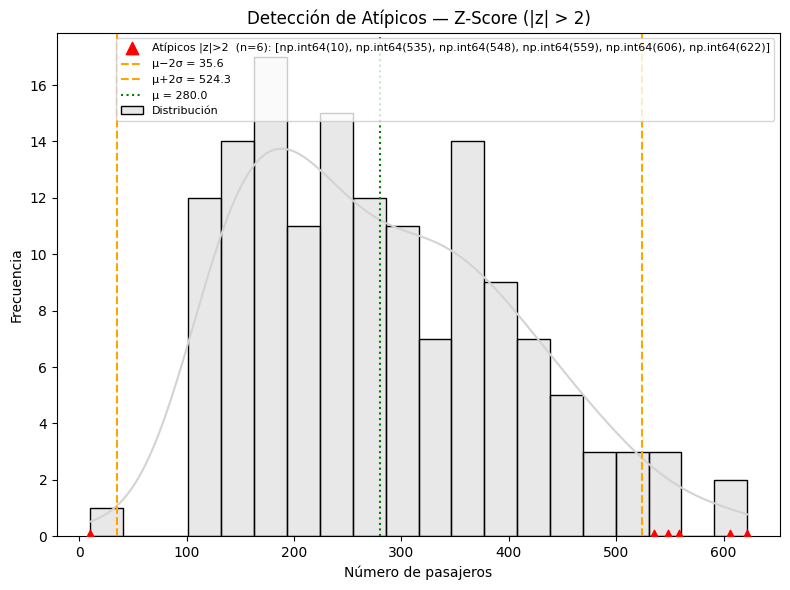

μ = 280.0,  σ = 122.2
Límites: [35.6, 524.3]
Atípicos detectados (6): [np.int64(10), np.int64(535), np.int64(548), np.int64(559), np.int64(606), np.int64(622)]


In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import zscore

# Datos
flights = sns.load_dataset("flights")
x = flights["passengers"].values
x = np.append(x, [10, 500])

# Z-Score
z_scores = zscore(x)
data_b = np.abs(z_scores) > 2

# Gráfico
plt.figure(figsize=(8, 6))
sns.histplot(x=x, bins=20, kde=True, color="lightgray", label="Distribución")

# Atípicos: se marcan en el eje x con un triángulo hacia arriba (^)
plt.scatter(x[data_b], np.zeros_like(x[data_b]), color="red", s=80, marker="^", zorder=5, label=f"Atípicos |z|>2  (n={data_b.sum()}): {sorted(x[data_b])}")

# Líneas de umbral μ ± 2σ equivalente
mean, std = x.mean(), x.std()
plt.axvline(mean - 2*std, color="orange", lw=1.5, linestyle="--", label=f"μ−2σ = {mean - 2*std:.1f}")
plt.axvline(mean + 2*std, color="orange", lw=1.5, linestyle="--", label=f"μ+2σ = {mean + 2*std:.1f}")
plt.axvline(mean,         color="green",  lw=1.5, linestyle=":",  label=f"μ = {mean:.1f}")

plt.title("Detección de Atípicos — Z-Score (|z| > 2)")
plt.xlabel("Número de pasajeros")
plt.ylabel("Frecuencia")
plt.legend(fontsize=8)
plt.tight_layout()
plt.show()

print(f"μ = {mean:.1f},  σ = {std:.1f}")
print(f"Límites: [{mean - 2*std:.1f}, {mean + 2*std:.1f}]")
print(f"Atípicos detectados ({data_b.sum()}): {sorted(x[data_b])}")

Mediante el criterio de z-score, se identifican 6 valores atípicos, correspondientes a observaciones que se encuentran fuera del rango definido por μ ± 2σ.
No obstante, la clasificación como atípicos depende del umbral seleccionado, por lo que con un criterio más estricto (por ejemplo, |z| > 3) podrían no considerarse como tales. Vemos que estos en realidad no estan fuera de la realidad, podria ser simplemente una mayor capacidad, más no un error en medida. Lo mismo ocurre con el limite inferior, no es anda raro que lleve pocos pasajeros, una avioneta por ejemplo.

# <span style="color:#2F749F;"><strong>Ejercicio 5: K-means</strong></span>

A partir de siguiente código:

1. Ajusta el código para mejorar la interpretación de la gráfica. Mínimo debes:
   - Indicar los nombres de los ejes
   - Incluir legenda para comprender lo que esté incluído en la gráfica
2. Generar máximo 5 líneas de análisis sobre lo que observas en términos de defición de atípicos sobre tú gráfica final

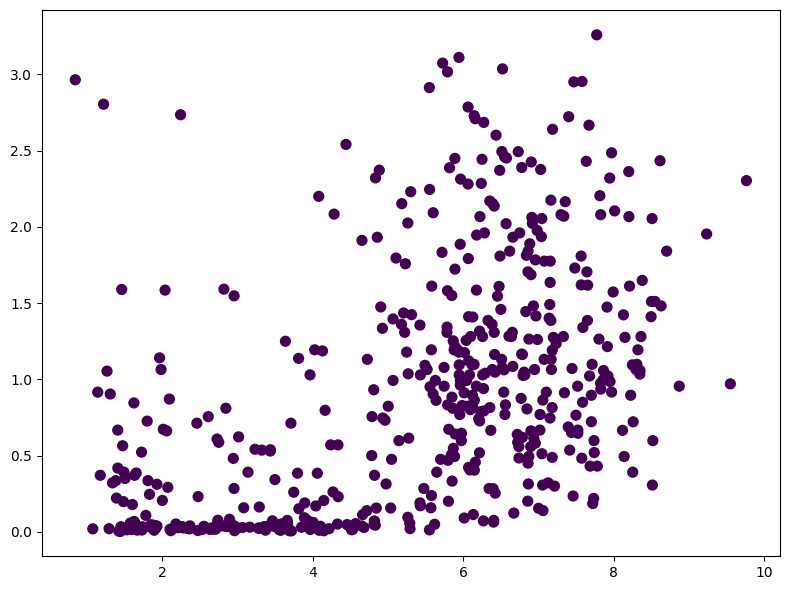

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
import numpy as np

planets = sns.load_dataset("planets").dropna(subset=["orbital_period", "mass"])
X = planets[["orbital_period", "mass"]].values
X = np.log1p(X)

kmeans = KMeans(n_clusters=1, random_state=42).fit(X)
labels = kmeans.labels_

plt.figure(figsize=(8,6))
plt.scatter(X[:,0], X[:,1], c=labels, cmap="viridis", s=50)
plt.tight_layout()
plt.show()
